# IT599 Capstone — FRESH Dataset EDA (aipick)
### Bridging the Precision Gap: Physics-Consistent World Models for Connector Grasping
**WF (WalshFarm) · Phase: EDA + Infra Setup**

---

FRESH = *Fusion-based 3D apple Recognition via Estimating Stem direction Heading* (Sejong RCV, Agriculture 2024).
RGB + Point Cloud fusion for **3D apple detection + stem 3-axis direction estimation**. KITTI-variant format, mmdet3d based.

**Confirmed dataset layout (papple_trainval, before create_data):**
```
<root>/
├── calib   (.txt)   depth  (.mat)   image  (.jpg)   label  (.txt)
├── train_data_idx.txt   val_data_idx.txt   test_data_idx.txt
```
> `points/` and `papple_infos_*.pkl` are produced later by `tools/create_data.py`. Depth here is analyzed directly (`.mat`).

**Confirmed label schema (14 numeric fields per object):**
| idx | field | meaning |
|----|-------|---------|
| 1-4 | x1 x2 y1 y2 | 2D bbox (pixels) |
| 5-7 | loc_x loc_y loc_z | 3D center (m, camera frame) |
| 8-10 | dim_h dim_w dim_l | dimensions (m; apple ≈ sphere → ~equal) |
| 11-13 | rot_x rot_y rot_z | **3-axis rotation (rad; stem direction; ~5° quantized)** |
| 14 | col14 | unknown (0-1) — candidate for heading scalar / score; verify vs paper |

**EDA goals (2 layers):**
1. **Understand the data** — inventory / splits / labels / distributions / depth / calib
2. **Grasp bridge** — map stem 3-axis rotation → grasp approach vector (the Precision Gap)

> Edit `DATA_ROOT` below. Missing folders/files are skipped automatically.

In [ ]:
# === 0. Config & Imports ===
from pathlib import Path
import os, glob, json, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_columns", 60)

# The FRESH source is not in this repository — its redistribution terms are unclear, so the
# repository ships this notebook instead and reproduces the derived data from a local copy.
#
# Point AIPICK_FRESH at the folder that directly contains calib/depth/image/label, or place
# that folder beside the notebooks as `papple_trainval/`. Resolving from the working directory
# rather than an absolute path means a clone runs without editing this cell.
DATA_ROOT = Path(os.environ.get("AIPICK_FRESH") or Path.cwd()/"papple_trainval")

TRAINVAL = DATA_ROOT
POINTS   = DATA_ROOT / "points"
SPLIT_FILES = {s: DATA_ROOT / f"{s}_data_idx.txt" for s in ["train","val","test"]}
INFO_PKLS   = {s: DATA_ROOT / f"papple_infos_{s}.pkl" for s in ["train","val","test"]}
FIG_DIR = Path("eda_figs"); FIG_DIR.mkdir(exist_ok=True)

def exists(p): return Path(p).exists()

print("DATA_ROOT:", DATA_ROOT, "|", "OK" if exists(DATA_ROOT) else "NOT FOUND")
if not exists(DATA_ROOT):
    print("\n  The FRESH dataset is not at that path. Obtain it from")
    print("    https://github.com/sejong-rcv/FRESH")
    print("  then set AIPICK_FRESH, or place papple_trainval/ beside this notebook.")
for sd in ["calib","depth","image","label"]:
    print(f"  {sd:6s}:", "OK" if exists(DATA_ROOT/sd) else "missing")
for s, p in SPLIT_FILES.items():
    print(f"  split[{s}]:", "OK" if exists(p) else "missing")
print("  points/:", "OK" if exists(POINTS) else "absent (created by create_data.py)")
print("  pkl    :", "OK" if any(exists(p) for p in INFO_PKLS.values()) else "absent (created by create_data.py)")


## 0b. Sample sanity check + point-cloud format discovery
**Important finding:** `depth/*.mat` is NOT a depth image — it holds an `(N, 6)` **point cloud**
(1300x1300 = 1,690,000 px, but the array is ~831k x 6). So `points/` already exists inside these
`.mat` files; `create_data.py` is not needed to obtain point clouds.

This section does not assume the column order. It **derives** it:
1. Print per-column stats (min/max/%negative) so the layout is visible
2. Try **every** 3-column triple as XYZ (a coordinate can coincidentally fall in [0,1] on one
   frame, so no columns are pre-excluded), projecting with the verified calib
   (`u = fx*X/(-Z)+cx`, `v = fy*(-Y)/(-Z)+cy`); the other 3 columns must look like color
3. Score each by **% of points landing inside the image** and **correlation between point RGB
   and the actual image pixel RGB** at the projected location
4. The winning assignment is stored in `PC` and reused by later sections

A correct assignment gives near-100% in-bounds and high RGB correlation. If `PC` stays empty or the
match is weak, the printed table shows it immediately instead of failing later.

In [ ]:
# === 0b. Sample sanity check + point cloud format discovery ===
import matplotlib.patches as patches
import matplotlib.image as mpimg
from scipy.io import loadmat
from itertools import permutations
import random

def read_label(p):
    rows = []
    for ln in open(p):
        t = ln.split()
        if t: rows.append((t[0], [float(x) for x in t[1:]]))
    return rows

def read_calib(p):
    mats = [np.array([float(x) for x in l.split()]).reshape(3,3) for l in open(p) if len(l.split()) == 9]
    R = mats[0] if mats else np.eye(3)
    K = mats[1].T if len(mats) > 1 else np.eye(3)   # file stores K transposed
    return R, K

def load_mat_array(p):
    # returns the largest numeric array in the .mat (the point cloud), shape (N, C)
    m = loadmat(str(p))
    arrs = {k: v for k, v in m.items() if not k.startswith("__") and hasattr(v, "ndim") and v.ndim == 2}
    if not arrs: return None, None
    k = max(arrs, key=lambda kk: arrs[kk].size)
    return np.asarray(arrs[k], dtype=np.float32), k

def project_xyz(xyz, K):
    # camera frame Y-up / Z-back (apple at Z<0); verified against label bbox centers
    X, Y, Z = xyz[:,0], xyz[:,1], xyz[:,2]
    d = -Z
    with np.errstate(divide="ignore", invalid="ignore"):
        u = K[0,0]*X/d + K[0,2]
        v = K[1,1]*(-Y)/d + K[1,2]
    return np.c_[u, v], d

img_dir = TRAINVAL/"image"
all_ids = sorted(p.stem for p in img_dir.glob("*.jpg")) if img_dir.exists() else []
print("images found:", len(all_ids))

# ---------- Grid: 6 random images + bbox overlay ----------
if all_ids:
    random.seed(0)
    for ax, sid in zip(plt.subplots(2, 3, figsize=(15, 8))[1].ravel(),
                       random.sample(all_ids, min(6, len(all_ids)))):
        ip = img_dir/f"{sid}.jpg"; lp = TRAINVAL/"label"/f"{sid}.txt"
        ax.imshow(plt.imread(str(ip))); ax.axis("off")
        n = 0
        if lp.exists():
            for c, v in read_label(lp):
                if len(v) >= 4:
                    x1, x2, y1, y2 = v[:4]
                    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                                 edgecolor="lime" if c == "apple" else "red", lw=1.3))
                    n += 1
        ax.set_title(f"{sid}  ({n} obj)", fontsize=9)
    plt.suptitle("Load check: random images + 2D bboxes", y=1.01)
    plt.tight_layout(); plt.savefig(FIG_DIR/"00_grid_check.png", bbox_inches="tight"); plt.show()

# ---------- Format discovery on one frame ----------
PC = {}          # resolved column mapping, reused later
SAMPLE = all_ids[0] if all_ids else None
if SAMPLE:
    ip = img_dir/f"{SAMPLE}.jpg"; dp = TRAINVAL/"depth"/f"{SAMPLE}.mat"
    lp = TRAINVAL/"label"/f"{SAMPLE}.txt"; cp = TRAINVAL/"calib"/f"{SAMPLE}.txt"
    print("\n[File presence]")
    for tag, p in [("image", ip), ("depth", dp), ("label", lp), ("calib", cp)]:
        print(f"  {tag:6s}:", "OK" if p.exists() else "MISSING")

    img = mpimg.imread(str(ip)); Hh, Ww = img.shape[:2]
    labels = read_label(lp)
    R, K = read_calib(cp)
    P, varname = load_mat_array(dp)
    print(f"\n[image] shape {img.shape}")
    print(f"[label] {len(labels)} objects")
    print(f"[calib] fx={K[0,0]:.1f} cx={K[0,2]:.2f} cy={K[1,2]:.2f}  R==I:{np.allclose(R,np.eye(3))}")
    print(f"[mat]   var='{varname}'  shape={P.shape}  -> point cloud, not a depth image")

    # per-column statistics
    print("\n[Column stats]")
    print(f"  {'col':>3} {'min':>10} {'max':>10} {'mean':>10} {'%neg':>7}")
    for j in range(P.shape[1]):
        c = P[:, j]
        print(f"  {j:>3} {c.min():>10.3f} {c.max():>10.3f} {c.mean():>10.3f} {(c<0).mean()*100:>6.1f}%")

    # ---- Resolve column mapping: brute force over ALL 3-col XYZ triples ----
    # (No pre-split: a coordinate column can coincidentally fall in [0,1] on a
    #  given frame, so we test every triple and let projection + RGB decide.)
    C = P.shape[1]
    sub = np.random.default_rng(0).choice(len(P), size=min(50000, len(P)), replace=False)
    Psub = P[sub]

    def rgb_scale_of(cols):
        return 255.0 if max(P[:,c].max() for c in cols) > 1.5 else 1.0

    results = []
    for perm in permutations(range(C), 3):
        rest = [c for c in range(C) if c not in perm]
        if len(rest) != 3: continue
        # remaining 3 must look like color: non-negative and bounded
        if not all(P[:,c].min() >= -0.02 for c in rest): continue
        scale = rgb_scale_of(rest)
        if not all(P[:,c].max() <= 1.02*scale for c in rest): continue

        xyz = Psub[:, list(perm)]
        uv, d = project_xyz(xyz, K)
        ok = np.isfinite(uv).all(1) & (d > 0)
        inb = ok & (uv[:,0] >= 0) & (uv[:,0] < Ww) & (uv[:,1] >= 0) & (uv[:,1] < Hh)
        frac = inb.mean()
        corr = np.nan
        if frac > 0.05:
            s = np.where(inb)[0]
            uu = uv[s,0].astype(int); vv = uv[s,1].astype(int)
            img_rgb = img[vv, uu][:, :3].astype(np.float32)
            if img_rgb.max() > 1.5: img_rgb /= 255.0
            pc_rgb = Psub[np.ix_(s, rest)] / scale
            cs = [np.corrcoef(pc_rgb[:,k], img_rgb[:,k])[0,1] for k in range(3)]
            corr = float(np.nanmean(cs))
        results.append((perm, tuple(rest), scale, frac, corr))

    # rank: highest RGB correlation first, then highest in-bounds fraction
    results.sort(key=lambda r: (-(r[4] if np.isfinite(r[4]) else -1), -r[3]))
    print("\n[XYZ triple scoring]  (want in-bounds ~100% and rgb corr ~1.0)")
    print(f"  {'xyz':>12} {'rgb':>10} {'in-bounds':>11} {'rgb corr':>10}")
    for perm, rest, scale, frac, corr in results[:8]:
        print(f"  {str(perm):>12} {str(rest):>10} {frac*100:>10.1f}% {corr:>10.3f}")

    if results:
        best = results[0]
        PC = dict(xyz=list(best[0]), rgb=list(best[1]), rgb_scale=best[2], var=varname)
        print(f"\n  ==> RESOLVED  xyz cols = {PC['xyz']}  rgb cols = {PC['rgb']}  (scale {PC['rgb_scale']:g})")
        print(f"      in-bounds {best[3]*100:.1f}%   rgb corr {best[4]:.3f}")
        if best[3] < 0.8 or not (best[4] > 0.5):
            print("      !! WEAK MATCH — inspect the column stats table above")
    else:
        print("\n  !! could not resolve columns — inspect the column stats table above")

# ---------- Visual confirmation ----------
if SAMPLE and PC:
    xyz = P[:, PC["xyz"]]
    uv, d = project_xyz(xyz, K)
    ok = np.isfinite(uv).all(1) & (d > 0) & (uv[:,0] >= 0) & (uv[:,0] < Ww) & (uv[:,1] >= 0) & (uv[:,1] < Hh)
    s = np.where(ok)[0]
    s = np.random.default_rng(0).choice(s, size=min(60000, len(s)), replace=False)

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax[0].imshow(img)
    for c, v in labels:
        if len(v) >= 4:
            x1, x2, y1, y2 = v[:4]
            ax[0].add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False,
                            edgecolor="lime" if c == "apple" else "red", lw=1.5))
        if len(v) >= 7:
            uu = K[0,0]*v[4]/(-v[6]) + K[0,2]; vv2 = K[1,1]*(-v[5])/(-v[6]) + K[1,2]
            ax[0].plot(uu, vv2, "y+", ms=12, mew=2)
    ax[0].set_title(f"{SAMPLE}.jpg (green=bbox, yellow+=projected 3D center)"); ax[0].axis("off")

    sc = ax[1].scatter(uv[s,0], uv[s,1], c=d[s], s=0.5, cmap="viridis")
    ax[1].set_xlim(0, Ww); ax[1].set_ylim(Hh, 0); ax[1].set_aspect("equal")
    ax[1].set_title("Point cloud projected to image (color = depth)"); ax[1].axis("off")
    plt.colorbar(sc, ax=ax[1], fraction=0.046)

    ax[2].scatter(xyz[s,0], xyz[s,2], c=d[s], s=0.5, cmap="viridis")
    ax[2].set_xlabel("X"); ax[2].set_ylabel("Z"); ax[2].set_title("Point cloud top-down (X vs Z)")
    plt.tight_layout(); plt.savefig(FIG_DIR/"00_sample_check.png", bbox_inches="tight"); plt.show()
    print("Middle panel should reproduce the scene layout; if it looks scrambled, the mapping is wrong.")

## 1. Inventory
File counts per folder, extensions, and cross-folder matching (missing / orphan files).

In [41]:
# === 1. Inventory ===
def scan(folder):
    folder = Path(folder)
    if not folder.exists(): return {}
    out = {}
    for p in folder.iterdir():
        if p.is_file(): out.setdefault(p.suffix.lower(), []).append(p.name)
    return out

for sd in ["calib","depth","image","label"]:
    files = scan(TRAINVAL/sd)
    n = sum(len(v) for v in files.values())
    print(f"{sd:7s}: {n:5d} files  exts={ {k:len(v) for k,v in files.items()} }")

def stems(folder):
    folder = Path(folder)
    return {p.stem for p in folder.iterdir() if p.is_file()} if folder.exists() else set()

s_img, s_lab = stems(TRAINVAL/"image"), stems(TRAINVAL/"label")
s_cal, s_dep = stems(TRAINVAL/"calib"), stems(TRAINVAL/"depth")
if s_img and s_lab:
    print("\n[Cross-folder matching]")
    print("  image & label :", len(s_img & s_lab))
    print("  image - label :", len(s_img - s_lab), "(image without label)")
    print("  label - image :", len(s_lab - s_img), "(label without image)")
    if s_cal: print("  image - calib :", len(s_img - s_cal))
    if s_dep: print("  image - depth :", len(s_img - s_dep))

calib  :  3383 files  exts={'.txt': 3383}
depth  :  3383 files  exts={'.mat': 3383}
image  :  3383 files  exts={'.jpg': 3383}
label  :  3383 files  exts={'.txt': 3383}

[Cross-folder matching]
  image & label : 3383
  image - label : 0 (image without label)
  label - image : 0 (label without image)
  image - calib : 0
  image - depth : 0


## 1b. Splits
Read `*_data_idx.txt`, report split sizes/ratios, check for leakage, and verify idx ↔ file matching. Raw idx lines are printed so the naming format is visible.

In [42]:
# === 1b. Splits ===
def read_idx(path):
    if not exists(path): return []
    with open(path) as f:
        return [ln.strip() for ln in f if ln.strip()]

splits_raw = {s: read_idx(p) for s, p in SPLIT_FILES.items()}
print("[Raw idx samples]")
for s, v in splits_raw.items():
    print(f"  {s}: n={len(v)}  first5={v[:5]}")

# normalize: idx files store unpadded ints ('458'), filenames are zero-padded ('000458')
def norm(x):
    s = os.path.splitext(os.path.basename(str(x)))[0]
    return s.zfill(6) if s.isdigit() else s
splits = {s: {norm(x) for x in v} for s, v in splits_raw.items()}
total = sum(len(v) for v in splits.values())
print("\n[Split sizes]")
for s, v in splits.items():
    print(f"  {s:5s}: {len(v):5d}  ({100*len(v)/total:4.1f}%)" if total else f"  {s}: 0")
print(f"  total: {total}")

tr, va, te = splits["train"], splits["val"], splits["test"]
print("\n[Leakage check] (want 0)")
print("  train&val:", len(tr&va), " train&test:", len(tr&te), " val&test:", len(va&te))

img_norm = {norm(x) for x in s_img}
if img_norm:
    allidx = tr|va|te
    print("\n[idx vs image matching (zero-padded)]")
    print("  idx present, image missing:", len(allidx - img_norm))
    print("  image present, idx missing:", len(img_norm - allidx),
          "<- expected 2: label files with no objects")

[Raw idx samples]
  train: n=1995  first5=['458', '459', '460', '461', '462']
  val: n=701  first5=['0', '1', '2', '3', '4']
  test: n=685  first5=['1971', '1972', '1973', '1974', '1975']

[Split sizes]
  train:  1995  (59.0%)
  val  :   701  (20.7%)
  test :   685  (20.3%)
  total: 3381

[Leakage check] (want 0)
  train&val: 0  train&test: 0  val&test: 0

[idx vs image matching (zero-padded)]
  idx present, image missing: 0
  image present, idx missing: 2 <- expected 2: label files with no objects


## 2. Label parsing (robust)
Auto-detect the numeric field count and print raw samples. Confirmed as 14 fields on this dataset; the parser still reports the count so any deviation is caught.

In [43]:
# === 2. Label parsing ===
def read_label_file(path):
    rows = []
    with open(path) as f:
        for line in f:
            t = line.split()
            if not t: continue
            cls = t[0]; vals = []
            for x in t[1:]:
                try: vals.append(float(x))
                except ValueError: vals.append(np.nan)
            rows.append((cls, vals))
    return rows

label_files = sorted((TRAINVAL/"label").glob("*.txt")) if exists(TRAINVAL/"label") else []
print("label files:", len(label_files))

ntok, samples = {}, []
for lf in label_files[:2000]:
    for cls, vals in read_label_file(lf):
        ntok[len(vals)] = ntok.get(len(vals), 0) + 1
        if len(samples) < 5: samples.append((lf.name, cls, vals))

print("numeric-field-count distribution:", dict(sorted(ntok.items())))
print("\nSample labels:")
for name, cls, vals in samples:
    print(f"  {name} | {cls:7s} | {['%.3f'%v for v in vals]}")

label files: 3383
numeric-field-count distribution: {14: 5045}

Sample labels:
  000000.txt | apple   | ['507.000', '669.000', '37.000', '187.000', '0.273', '-0.044', '-2.810', '0.072', '0.072', '0.072', '0.000', '0.175', '1.745', '0.193']
  000001.txt | apple   | ['619.000', '795.000', '225.000', '391.000', '0.323', '-0.137', '-2.740', '0.075', '0.075', '0.075', '0.087', '-0.087', '2.793', '0.443']
  000001.txt | apple   | ['524.000', '690.000', '578.000', '746.000', '0.276', '-0.306', '-2.744', '0.072', '0.072', '0.072', '0.000', '0.175', '1.833', '0.857']
  000001.txt | apple   | ['793.000', '1012.000', '328.000', '531.000', '0.375', '-0.175', '-2.468', '0.082', '0.082', '0.082', '0.000', '0.087', '1.309', '0.967']
  000001.txt | apple   | ['449.000', '662.000', '178.000', '382.000', '0.224', '-0.110', '-2.454', '0.084', '0.084', '0.084', '0.000', '0.175', '2.007', '0.530']


In [44]:
# === 2b. Labels -> DataFrame (confirmed FRESH schema) ===
FRESH_COLS = ["x1","x2","y1","y2",              # 2D bbox (pixels)
              "loc_x","loc_y","loc_z",           # 3D center (m, camera frame)
              "dim_h","dim_w","dim_l",           # dimensions (m; apple ~ sphere)
              "rot_x","rot_y","rot_z",           # 3-axis rotation (rad; stem direction)
              "col14"]                            # unknown (0-1); verify vs paper

recs = []
for lf in label_files:
    for cls, vals in read_label_file(lf):
        r = {"file": lf.stem, "cls": cls, "n_num": len(vals)}
        for i, name in enumerate(FRESH_COLS):
            r[name] = vals[i] if i < len(vals) else np.nan
        recs.append(r)

lab = pd.DataFrame(recs)
print("objects:", len(lab), "| images:", lab["file"].nunique())
print("class counts:\n", lab["cls"].value_counts())
# keep apples only for geometry analysis
apples = lab[lab["cls"] == "apple"].copy()
print("\napples:", len(apples))
lab.head()

objects: 9044 | images: 3381
class counts:
 cls
apple     9040
ignore       4
Name: count, dtype: int64

apples: 9040


,file,cls,n_num,x1,x2,y1,y2,loc_x,loc_y,loc_z,dim_h,dim_w,dim_l,rot_x,rot_y,rot_z,col14
0,000000,apple,14,507.0,669.0,37.0,187.0,0.273326,-0.044207,-2.810338,0.0724,0.0724,0.0724,0.000000,0.174533,1.745329,0.192966
1,000001,apple,14,619.0,795.0,225.0,391.0,0.323098,-0.136645,-2.739553,0.0754,0.0754,0.0754,0.087266,-0.087266,2.792527,0.442590
2,000001,apple,14,524.0,690.0,578.0,746.0,0.275936,-0.305547,-2.744283,0.0724,0.0724,0.0724,0.000000,0.174533,1.832596,0.856709
3,000001,apple,14,793.0,1012.0,328.0,531.0,0.374613,-0.175049,-2.467927,0.0816,0.0816,0.0816,0.000000,0.087266,1.308997,0.967233
4,000001,apple,14,449.0,662.0,178.0,382.0,0.224499,-0.110279,-2.453786,0.0835,0.0835,0.0835,0.000000,0.174533,2.007129,0.530132


## 3. Basic distributions
Apples per image, apple size (h/w/l), 3D location. Uses apples only (ignore class excluded).

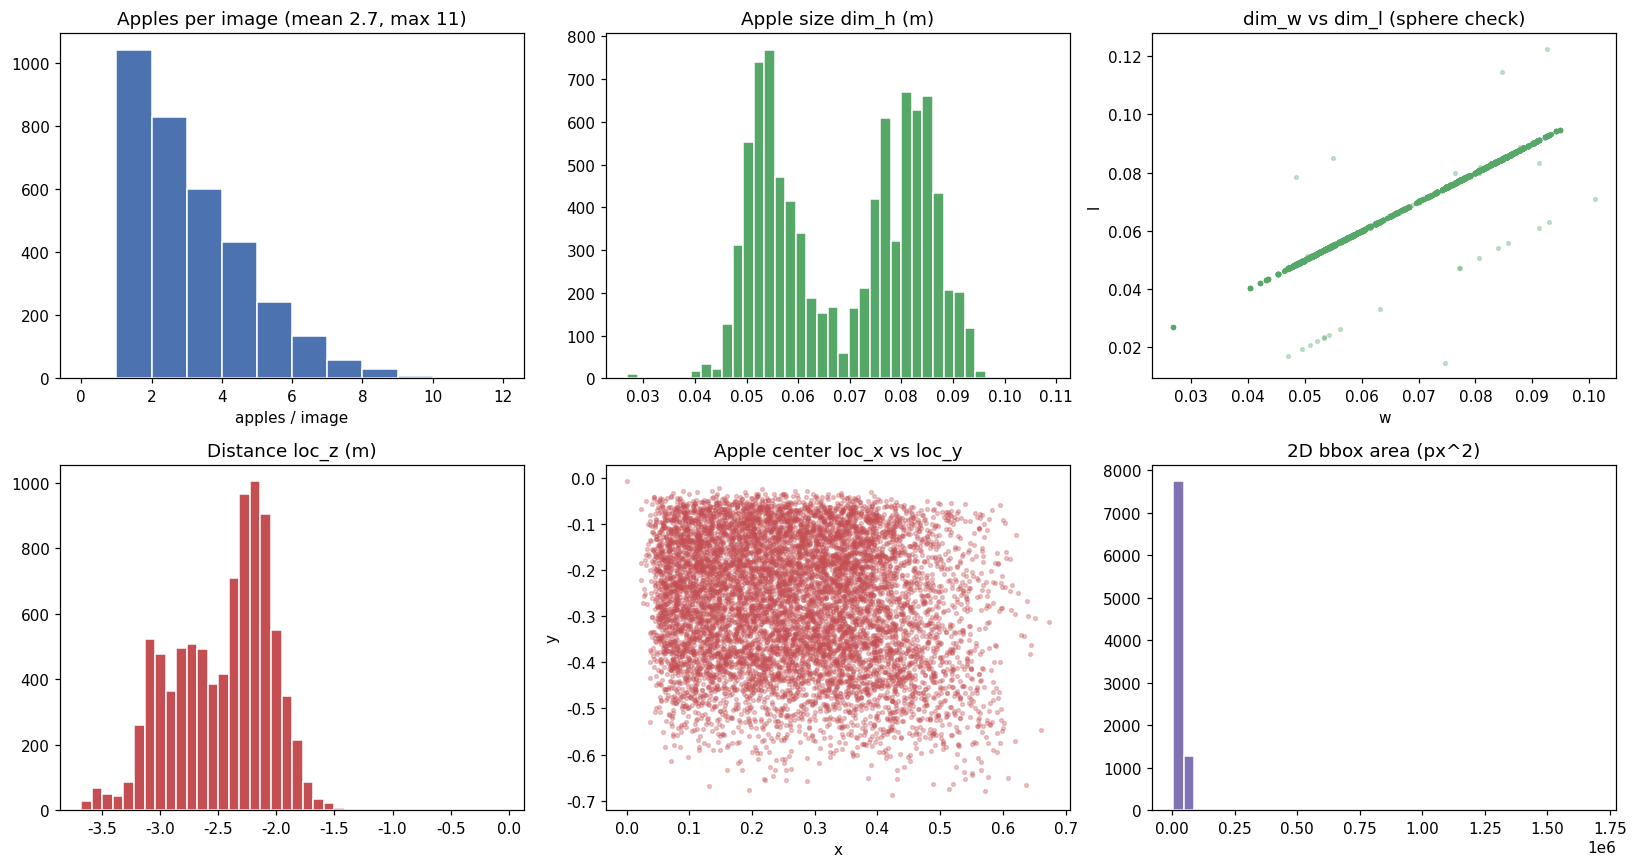

size ~equal? std of (h,w,l) per object: 5e-05 (≈0 → sphere)


In [45]:
# === 3. Distributions ===
if len(apples):
    per_img = apples.groupby("file").size()
    fig, ax = plt.subplots(2, 3, figsize=(15, 8))

    ax[0,0].hist(per_img, bins=range(0, per_img.max()+2), color="#4C72B0", edgecolor="w")
    ax[0,0].set_title(f"Apples per image (mean {per_img.mean():.1f}, max {per_img.max()})")
    ax[0,0].set_xlabel("apples / image")

    ax[0,1].hist(apples["dim_h"].dropna(), bins=40, color="#55A868", edgecolor="w")
    ax[0,1].set_title("Apple size dim_h (m)")
    ax[0,2].scatter(apples["dim_w"], apples["dim_l"], s=6, alpha=0.3, color="#55A868")
    ax[0,2].set_title("dim_w vs dim_l (sphere check)"); ax[0,2].set_xlabel("w"); ax[0,2].set_ylabel("l")

    ax[1,0].hist(apples["loc_z"].dropna(), bins=40, color="#C44E52", edgecolor="w")
    ax[1,0].set_title("Distance loc_z (m)")
    ax[1,1].scatter(apples["loc_x"], apples["loc_y"], s=6, alpha=0.3, color="#C44E52")
    ax[1,1].set_title("Apple center loc_x vs loc_y"); ax[1,1].set_xlabel("x"); ax[1,1].set_ylabel("y")

    # bbox area distribution
    bw = (apples["x2"]-apples["x1"]).abs(); bh = (apples["y2"]-apples["y1"]).abs()
    ax[1,2].hist((bw*bh).dropna(), bins=40, color="#8172B3", edgecolor="w")
    ax[1,2].set_title("2D bbox area (px^2)")

    plt.tight_layout(); plt.savefig(FIG_DIR/"01_distributions.png", bbox_inches="tight"); plt.show()

    print("size ~equal? std of (h,w,l) per object:",
          apples[["dim_h","dim_w","dim_l"]].std(axis=1).mean().round(5), "(≈0 → sphere)")
else:
    print("no apple rows")

## 4. Stem heading — 3-axis rotation (key target)
`rot_x, rot_y, rot_z` describe the stem direction. These are the variables the World Model must predict, so bias here (angle clustering) directly affects training. Values are ~5° quantized; rot_z is typically the dominant axis.

rotation columns: ['rot_x', 'rot_y', 'rot_z']


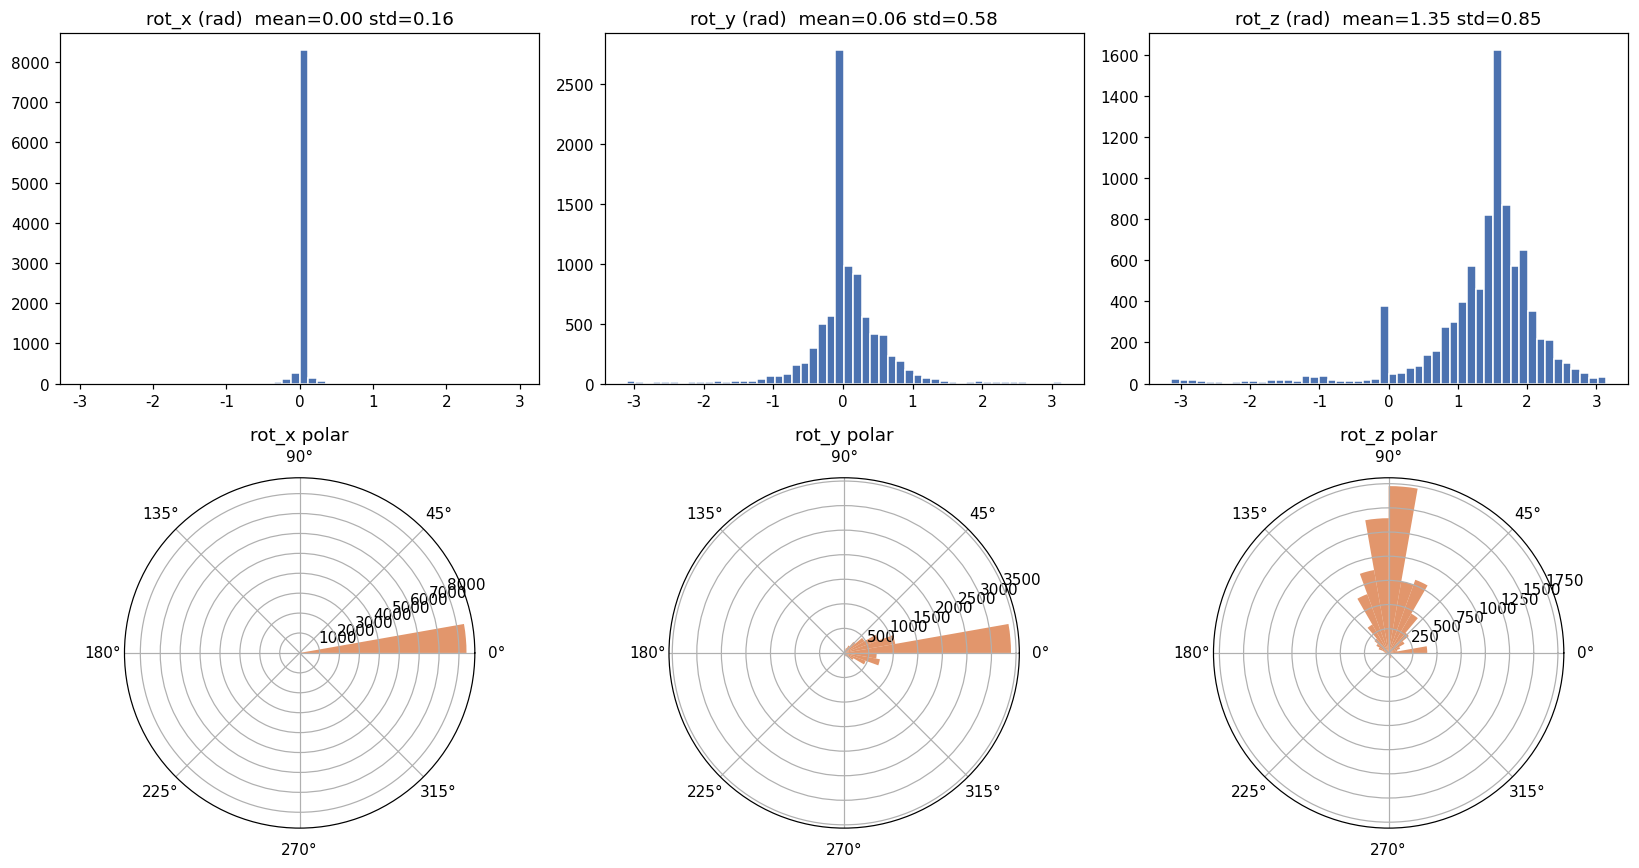


[Bias diagnostics] (|skew|>1 -> notable clustering)
  rot_x: range=[-2.97,2.97] std=0.16 skew=-0.21
  rot_y: range=[-3.11,3.14] std=0.58 skew=-0.37
  rot_z: range=[-3.14,3.14] std=0.85 skew=-2.04

[Quantization] unique values in rot_z (deg):
   [-180. -179. -178. -177. -176. -175. -174. -173. -172. -171. -170. -168.
 -167. -166. -165. -163. -162. -161. -160. -159.] ...


In [46]:
# === 4. Stem 3-axis rotation ===
rot_cols = [c for c in ["rot_x","rot_y","rot_z"] if c in apples and apples[c].notna().any()]
print("rotation columns:", rot_cols)

if rot_cols:
    n = len(rot_cols)
    fig = plt.figure(figsize=(5*n, 8))
    for i, col in enumerate(rot_cols):
        v = apples[col].dropna().values
        unit = "rad" if np.nanmax(np.abs(v)) <= (2*np.pi+0.1) else "deg"
        ax1 = fig.add_subplot(2, n, i+1)
        ax1.hist(v, bins=50, color="#4C72B0", edgecolor="w")
        ax1.set_title(f"{col} ({unit})  mean={v.mean():.2f} std={v.std():.2f}")
        ax2 = fig.add_subplot(2, n, n+i+1, projection="polar")
        rad = v if unit=="rad" else np.deg2rad(v)
        cnt, edges = np.histogram(rad, bins=36, range=(-np.pi, np.pi))
        ax2.bar((edges[:-1]+edges[1:])/2, cnt, width=2*np.pi/36, color="#DD8452", alpha=0.85)
        ax2.set_title(f"{col} polar")
    plt.tight_layout(); plt.savefig(FIG_DIR/"02_stem_rotation.png", bbox_inches="tight"); plt.show()

    print("\n[Bias diagnostics] (|skew|>1 -> notable clustering)")
    for col in rot_cols:
        v = apples[col].dropna()
        print(f"  {col}: range=[{v.min():.2f},{v.max():.2f}] std={v.std():.2f} skew={v.skew():.2f}")

    # quantization check
    print("\n[Quantization] unique values in rot_z (deg):")
    uz = np.round(np.rad2deg(apples['rot_z'].dropna().unique()),1)
    print("  ", np.sort(np.unique(uz))[:20], "...")
else:
    print("no rotation columns")

## 4b. col14 — identify the unknown field
The 14th field is in [0,1]. Plot its distribution and correlation with rot_z to guess whether it is a heading scalar, a score, or a normalized angle.

corr(col14, rot_z) = 0.081


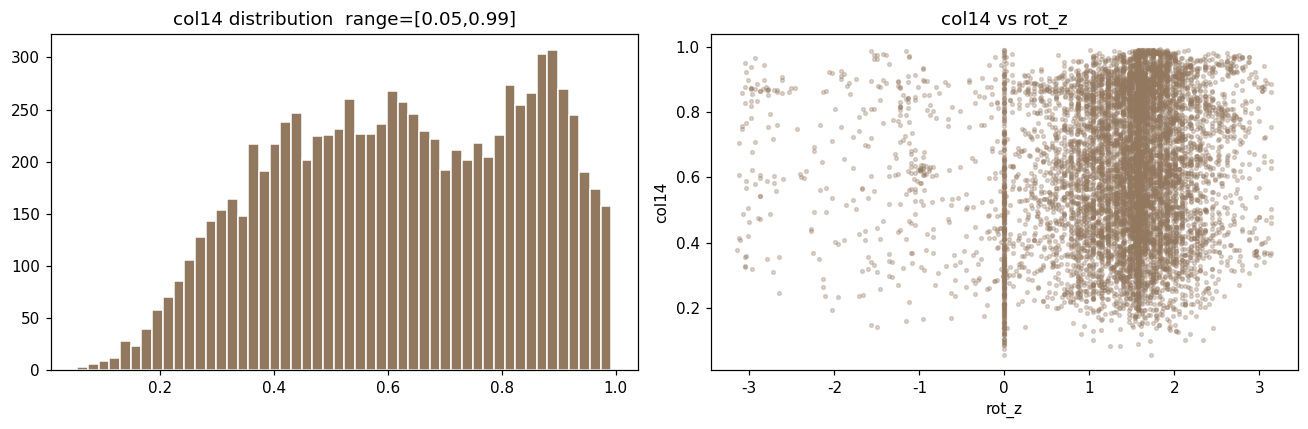

Hint: near-uniform [0,1] with low corr -> likely a score/visibility;
      strong corr with an angle -> normalized heading. Confirm against the paper/config.


In [47]:
# === 4b. col14 investigation ===
if "col14" in apples and apples["col14"].notna().any():
    c = apples["col14"].dropna()
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(c, bins=50, color="#937860", edgecolor="w")
    ax[0].set_title(f"col14 distribution  range=[{c.min():.2f},{c.max():.2f}]")
    if "rot_z" in apples:
        ax[1].scatter(apples["rot_z"], apples["col14"], s=6, alpha=0.3, color="#937860")
        ax[1].set_title("col14 vs rot_z"); ax[1].set_xlabel("rot_z"); ax[1].set_ylabel("col14")
        corr = apples[["rot_z","col14"]].corr().iloc[0,1]
        print(f"corr(col14, rot_z) = {corr:.3f}")
    plt.tight_layout(); plt.savefig(FIG_DIR/"02b_col14.png", bbox_inches="tight"); plt.show()
    print("Hint: near-uniform [0,1] with low corr -> likely a score/visibility;")
    print("      strong corr with an angle -> normalized heading. Confirm against the paper/config.")
else:
    print("col14 absent")

## 5. Point cloud statistics (from `depth/*.mat`)
Now that §0b resolved the column mapping, analyze the point clouds properly: points per frame,
spatial extent, depth range vs the label `loc_z`, and the fraction of points projecting into the
image. The old "valid depth ratio ≈ 66%" was an artifact of treating a point list as an image —
ignore it.

point cloud .mat files: 3383
points per frame : mean 618,523  min 79,450  max 934,506
Z range          : [-5.00, -1.19] m  (labels loc_z ~ -3.68..-0.05)
X spread / frame : mean 0.65 m   Y spread: mean 0.59 m
project in-bounds: mean 100.0%  min 100.0%


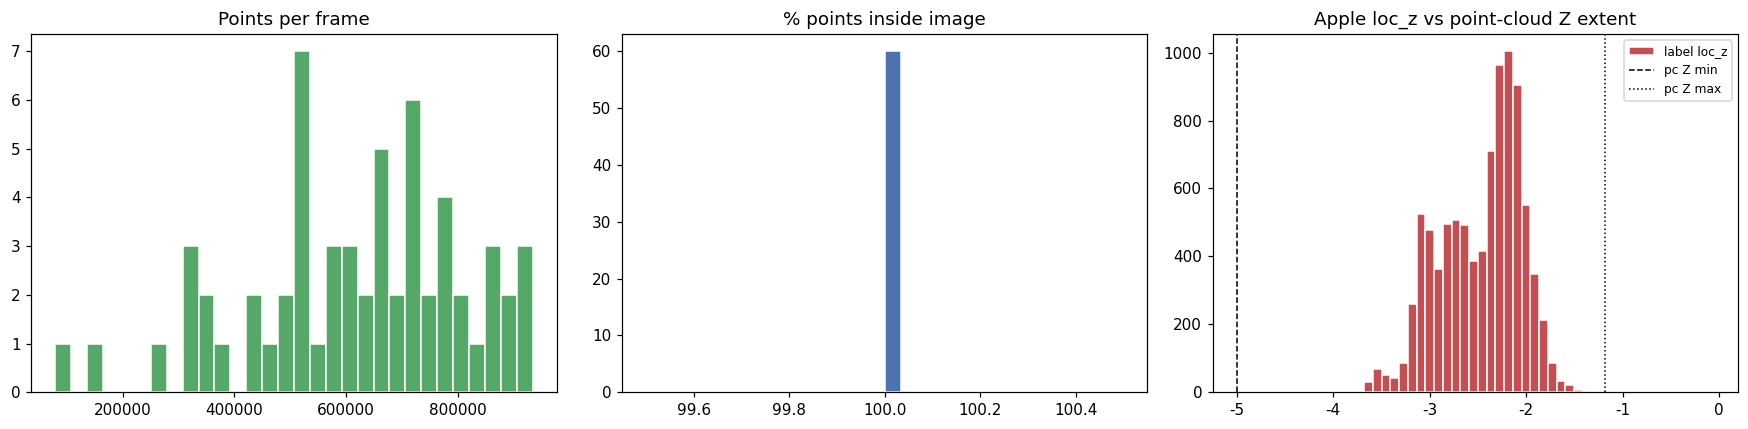

In [48]:
# === 5. Point cloud statistics ===
mat_files = sorted((TRAINVAL/"depth").glob("*.mat")) if exists(TRAINVAL/"depth") else []
print("point cloud .mat files:", len(mat_files))

if mat_files and PC:
    N_SAMPLE = 60                       # frames to sample (each has ~800k points)
    rng = np.random.default_rng(0)
    pick = [mat_files[i] for i in rng.choice(len(mat_files), min(N_SAMPLE, len(mat_files)), replace=False)]

    n_pts, zmin, zmax, xr, yr, inb_frac = [], [], [], [], [], []
    for mf in pick:
        Pm, _ = load_mat_array(mf)
        if Pm is None or Pm.shape[1] <= max(PC["xyz"]): continue
        xyz = Pm[:, PC["xyz"]]
        n_pts.append(len(xyz))
        zmin.append(xyz[:,2].min()); zmax.append(xyz[:,2].max())
        xr.append(np.ptp(xyz[:,0])); yr.append(np.ptp(xyz[:,1]))
        _, Kf = read_calib(TRAINVAL/"calib"/f"{mf.stem}.txt")
        uv, d = project_xyz(xyz, Kf)
        inb = np.isfinite(uv).all(1) & (d > 0) & (uv[:,0] >= 0) & (uv[:,0] < 1300) & (uv[:,1] >= 0) & (uv[:,1] < 1300)
        inb_frac.append(inb.mean())

    n_pts = np.array(n_pts); inb_frac = np.array(inb_frac)
    print(f"points per frame : mean {n_pts.mean():,.0f}  min {n_pts.min():,}  max {n_pts.max():,}")
    print(f"Z range          : [{np.min(zmin):.2f}, {np.max(zmax):.2f}] m  (labels loc_z ~ {apples['loc_z'].min():.2f}..{apples['loc_z'].max():.2f})")
    print(f"X spread / frame : mean {np.mean(xr):.2f} m   Y spread: mean {np.mean(yr):.2f} m")
    print(f"project in-bounds: mean {inb_frac.mean()*100:.1f}%  min {inb_frac.min()*100:.1f}%")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].hist(n_pts, bins=30, color="#55A868", edgecolor="w"); ax[0].set_title("Points per frame")
    ax[1].hist(inb_frac*100, bins=30, color="#4C72B0", edgecolor="w"); ax[1].set_title("% points inside image")
    ax[2].hist(apples["loc_z"].dropna(), bins=40, color="#C44E52", edgecolor="w", label="label loc_z")
    ax[2].axvline(np.min(zmin), color="k", ls="--", lw=1, label="pc Z min")
    ax[2].axvline(np.max(zmax), color="k", ls=":", lw=1, label="pc Z max")
    ax[2].set_title("Apple loc_z vs point-cloud Z extent"); ax[2].legend(fontsize=8)
    plt.tight_layout(); plt.savefig(FIG_DIR/"03_pointcloud.png", bbox_inches="tight"); plt.show()
else:
    print("no .mat files, or PC mapping unresolved (run 0b first)")

## 6. mmdet3d info (.pkl)
Generated after `create_data.py`. Not required for the point clouds (they are already in the `.mat` files), but useful to confirm the official rotation/annotation field names. Auto-skips if absent.

In [49]:
# === 6. info pkl structure ===
def peek(o, depth=0, maxd=3):
    ind = "  "*depth
    if depth > maxd: return
    if isinstance(o, dict):
        for k, v in o.items():
            extra = ""
            if isinstance(v, np.ndarray): extra = f" shape={v.shape} {v.dtype}"
            elif isinstance(v, (list, tuple)): extra = f" len={len(v)}"
            print(f"{ind}{k}: {type(v).__name__}{extra}")
            if isinstance(v, dict): peek(v, depth+1, maxd)
            elif isinstance(v, (list, tuple)) and v and isinstance(v[0], dict): peek(v[0], depth+1, maxd)

any_pkl = False
for split, p in INFO_PKLS.items():
    if not exists(p): continue
    any_pkl = True
    with open(p, "rb") as f: infos = pickle.load(f)
    data = infos["data_list"] if isinstance(infos, dict) and "data_list" in infos else infos
    print(f"\n===== {split}: {len(data)} samples =====")
    peek(data[0])
if not any_pkl:
    print("No .pkl yet. Run: python tools/create_data.py papple --root-path <data> --out-dir <data> --extra-tag papple")

No .pkl yet. Run: python tools/create_data.py papple --root-path <data> --out-dir <data> --extra-tag papple


## 7. Calibration (confirmed)
FRESH calib = two 3x3 matrices (no `key:` labels):
- **line 1** = 3x3 identity -> extrinsic rotation R = I (camera frame == world frame)
- **line 2** = intrinsic K stored transposed: fx = fy ≈ 5750.57, cx ≈ 28.56, cy ≈ 21.06

Camera convention is Y-up / Z-back (apple at Z<0), so projection is:
`u = fx*X/(-Z) + cx`, `v = fy*(-Y)/(-Z) + cy`.
Verified: projecting a label's 3D center lands on its 2D bbox center. This cell reports the mean reprojection error to bbox centers as a sanity check.

R (extrinsic):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

K (intrinsic):
 [[5.75057262e+03 0.00000000e+00 2.85614800e+01]
 [0.00000000e+00 5.75057262e+03 2.10631330e+01]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

fx=5750.57 fy=5750.57 cx=28.56 cy=21.06
R == I ? True

[Reprojection error to bbox center]  mean=1.0px  median=0.8px
(small error confirms the projection model + shared calib assumption)


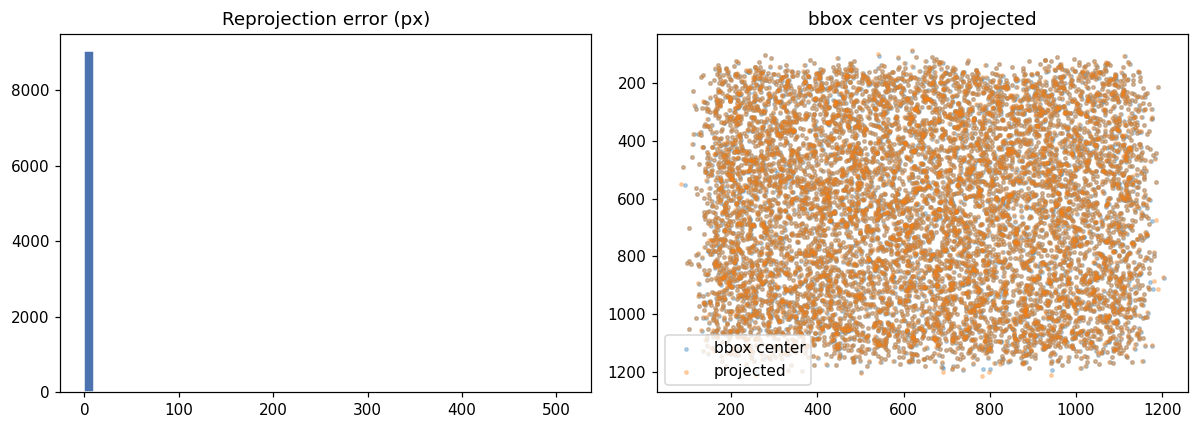

In [50]:
# === 7. Calib parse + projection sanity ===
def parse_calib(path):
    # Two 3x3 matrices: line1 = R (extrinsic), line2 = K transposed (intrinsic)
    rows = []
    for l in open(path):
        nums = [float(x) for x in l.split()]
        if len(nums) == 9: rows.append(np.array(nums).reshape(3, 3))
    R  = rows[0] if len(rows) >= 1 else np.eye(3)
    Kt = rows[1] if len(rows) >= 2 else np.eye(3)
    K  = Kt.T                       # file stores K transposed
    return R, K

def project(loc, K):
    # loc: (N,3) camera coords, Y-up/Z-back. Returns pixel (N,2).
    X, Y, Z = loc[:,0], loc[:,1], loc[:,2]
    d = -Z                          # positive depth
    fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
    u = fx * X / d + cx
    v = fy * (-Y) / d + cy
    return np.c_[u, v]

calib_files = sorted((TRAINVAL/"calib").glob("*.txt")) if exists(TRAINVAL/"calib") else []
if calib_files:
    R, K = parse_calib(calib_files[0])
    print("R (extrinsic):\n", R)
    print("\nK (intrinsic):\n", K)
    print(f"\nfx={K[0,0]:.2f} fy={K[1,1]:.2f} cx={K[0,2]:.2f} cy={K[1,2]:.2f}")
    print("R == I ?", np.allclose(R, np.eye(3)))

    # Reprojection sanity: project each apple's 3D center, compare to its 2D bbox center.
    # (assumes shared intrinsics; if per-frame calib differs, load per file.)
    a = apples.dropna(subset=["loc_x","loc_y","loc_z","x1","x2","y1","y2"]).copy()
    loc = a[["loc_x","loc_y","loc_z"]].values
    uv = project(loc, K)
    cx_box = (a["x1"].values + a["x2"].values) / 2
    cy_box = (a["y1"].values + a["y2"].values) / 2
    err = np.sqrt((uv[:,0]-cx_box)**2 + (uv[:,1]-cy_box)**2)
    print(f"\n[Reprojection error to bbox center]  mean={err.mean():.1f}px  median={np.median(err):.1f}px")
    print("(small error confirms the projection model + shared calib assumption)")

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].hist(err, bins=50, color="#4C72B0", edgecolor="w"); ax[0].set_title("Reprojection error (px)")
    ax[1].scatter(cx_box, cy_box, s=5, alpha=0.3, label="bbox center")
    ax[1].scatter(uv[:,0], uv[:,1], s=5, alpha=0.3, label="projected")
    ax[1].invert_yaxis(); ax[1].legend(); ax[1].set_title("bbox center vs projected")
    plt.tight_layout(); plt.savefig(FIG_DIR/"05_reprojection.png", bbox_inches="tight"); plt.show()
else:
    print("no calib files")

## 8. Grasp bridge — rotation → approach vector (Precision Gap)
FRESH has no grasp pose. We reinterpret the stem 3-axis rotation as a stem direction, and take the **opposite** vector as the first candidate gripper approach. The spread of approach directions previews how varied the grasp trajectories will be in PyBullet.

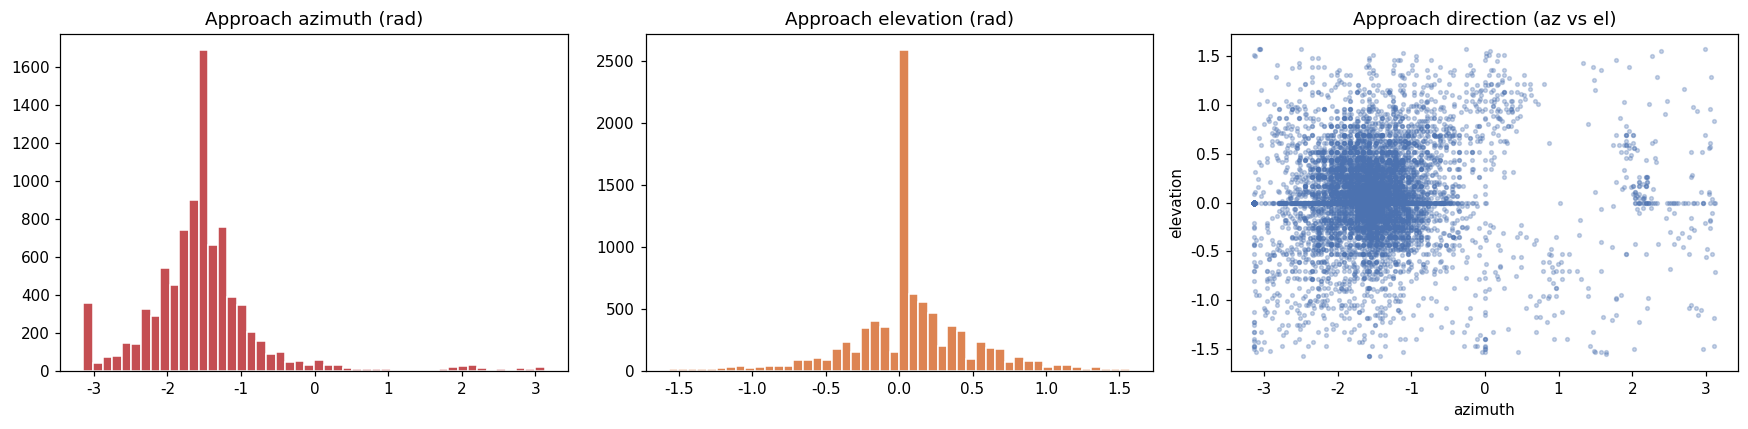

[Grasp bridge diagnostics]
  azimuth   std = 0.861 rad
  elevation std = 0.438 rad
  larger spread -> more diverse grasp trajectories for the World Model to learn.
  strong clustering -> consider resampling / augmentation in the PyBullet scenarios.


In [51]:
# === 8. Stem rotation -> 3D approach vector ===
def euler_to_dir(rx, ry, rz):
    # The stem is the +X body axis, NOT +Z. The diagnostic over all 9,040 apples showed the
    # +Z column is the camera ray (64% of stems within 20 deg of it), while +X points up for
    # 92% of apples and is independent of rot_x — consistent with rot_x being the unobservable
    # roll about the stalk (0 for 89% of apples). This returns the +X column of Rz@Ry@Rx,
    # which does not depend on rx.
    cz, sz = np.cos(rz), np.sin(rz); cy, sy = np.cos(ry), np.sin(ry)
    x = cz*cy
    y = sz*cy
    z = -sy
    return np.stack([x, y, z], axis=1)

if all(c in apples for c in ["rot_x","rot_y","rot_z"]):
    a = apples.dropna(subset=["rot_x","rot_y","rot_z"])
    stem_dir = euler_to_dir(a["rot_x"].values, a["rot_y"].values, a["rot_z"].values)
    approach = -stem_dir  # gripper approaches opposite the stem
    az = np.arctan2(approach[:,1], approach[:,0])         # azimuth
    el = np.arcsin(np.clip(approach[:,2], -1, 1))         # elevation

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].hist(az, bins=48, color="#C44E52", edgecolor="w"); ax[0].set_title("Approach azimuth (rad)")
    ax[1].hist(el, bins=48, color="#DD8452", edgecolor="w"); ax[1].set_title("Approach elevation (rad)")
    ax[2].scatter(az, el, s=6, alpha=0.3, color="#4C72B0")
    ax[2].set_title("Approach direction (az vs el)"); ax[2].set_xlabel("azimuth"); ax[2].set_ylabel("elevation")
    plt.tight_layout(); plt.savefig(FIG_DIR/"04_grasp_approach.png", bbox_inches="tight"); plt.show()

    print("[Grasp bridge diagnostics]")
    print(f"  azimuth   std = {az.std():.3f} rad")
    print(f"  elevation std = {el.std():.3f} rad")
    print("  larger spread -> more diverse grasp trajectories for the World Model to learn.")
    print("  strong clustering -> consider resampling / augmentation in the PyBullet scenarios.")
else:
    print("rotation columns missing")

## 9. Image / apple filtering
FRESH is a detection set; not every apple is a good grasp target. Compute per-apple quality features (cheap, no I/O) and see how many survive each rule, then set the `FILTER` thresholds from the distributions.

Rules: drop `ignore`, drop too-small bboxes (far/few pixels), drop border-truncated apples (partially outside frame). Depth-coverage filtering happens in §10 where depth is loaded anyway.

image size: 1300 x 1300


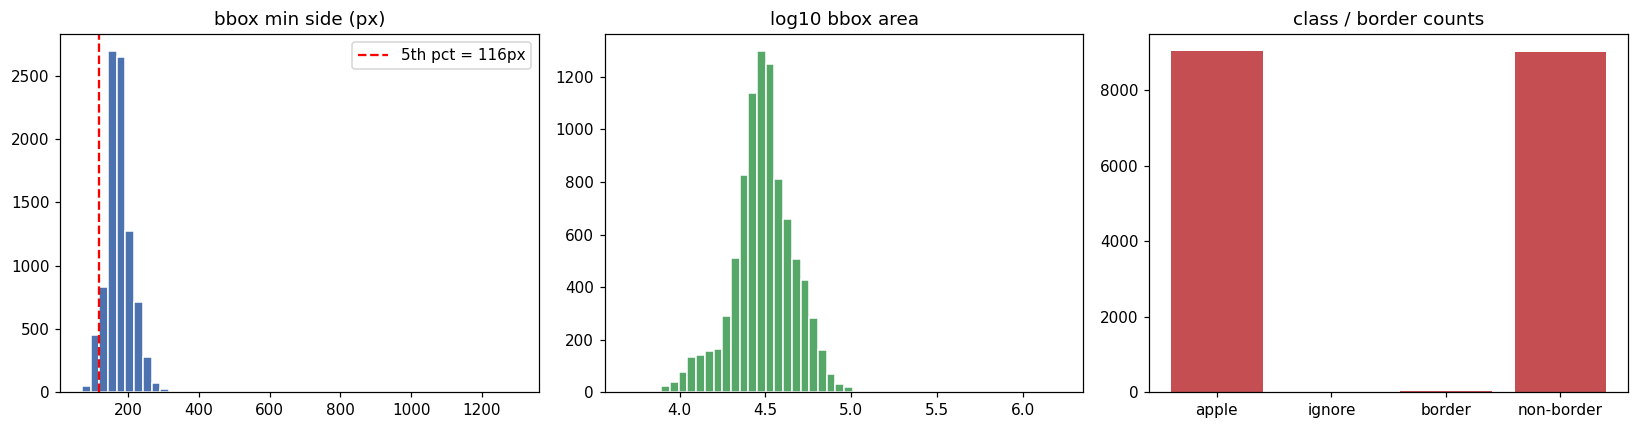


min_side_px set to 2nd percentile = 104px
min_visibility (col14) = 0.3

[Survival]  (cumulative)
  total objects            : 9044
  after drop ignore        : 9040
  after min_side>=104px      : 8873
  after drop border        : 8843
  after visibility>=0.3     : 8134   (<- final target for extraction)
  frames retained          : 3263 / 3381


In [37]:
# === 9. Filtering criteria ===
# image size (assume constant; read one sample)
import matplotlib.image as mpimg
sample_img = next((TRAINVAL/"image").glob("*.jpg"), None)
if sample_img is not None:
    H, W = mpimg.imread(str(sample_img)).shape[:2]
else:
    W, H = 1024, 768
print(f"image size: {W} x {H}")

f = lab.copy()
f["bw"] = (f["x2"] - f["x1"]).abs()
f["bh"] = (f["y2"] - f["y1"]).abs()
f["min_side"] = f[["bw","bh"]].min(axis=1)
f["area"] = f["bw"] * f["bh"]
BORDER = 3   # px tolerance for "touching edge"
f["is_border"] = ((f["x1"] <= BORDER) | (f["y1"] <= BORDER) |
                  (f["x2"] >= W-BORDER) | (f["y2"] >= H-BORDER))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(f["min_side"].dropna(), bins=50, color="#4C72B0", edgecolor="w")
ax[0].set_title("bbox min side (px)")
ax[0].axvline(f["min_side"].quantile(0.05), color="r", ls="--",
              label=f"5th pct = {f['min_side'].quantile(0.05):.0f}px")
ax[0].legend()
ax[1].hist(np.log10(f["area"].replace(0, np.nan).dropna()), bins=50, color="#55A868", edgecolor="w")
ax[1].set_title("log10 bbox area")
ax[2].bar(["apple","ignore","border","non-border"],
          [ (f["cls"]=="apple").sum(), (f["cls"]=="ignore").sum(),
            f["is_border"].sum(), (~f["is_border"]).sum() ], color="#C44E52")
ax[2].set_title("class / border counts")
plt.tight_layout(); plt.savefig(FIG_DIR/"06_filter_features.png", bbox_inches="tight"); plt.show()

# ---- FILTER config ----
# min_side=20 removed 0 objects (apples ~160-220px in 1300x1300) -> use data-driven floor.
# col14 = visibility (confirmed: modal/amodal mask IoU; 1=fully visible, lower=more occluded).
FILTER = dict(drop_ignore=True,
              min_side_px=float(f.loc[f["cls"]=="apple", "min_side"].quantile(0.02)),
              drop_border=True,
              min_visibility=0.3)     # drop heavily occluded apples; tune from col14 histogram (4b)
print(f"\nmin_side_px set to 2nd percentile = {FILTER['min_side_px']:.0f}px")
print(f"min_visibility (col14) = {FILTER['min_visibility']}")

# cumulative masks so the survival table is correct regardless of order
m_cls  = (f["cls"] == "apple") if FILTER["drop_ignore"] else pd.Series(True, index=f.index)
m_side = m_cls  & (f["min_side"] >= FILTER["min_side_px"] if FILTER["min_side_px"] else True)
m_bord = m_side & (~f["is_border"] if FILTER["drop_border"] else True)
m_vis  = m_bord & (f["col14"] >= FILTER["min_visibility"] if FILTER["min_visibility"] is not None else True)

filtered = f[m_vis].copy()
print("\n[Survival]  (cumulative)")
print(f"  total objects            : {len(f)}")
print(f"  after drop ignore        : {m_cls.sum()}")
print(f"  after min_side>={FILTER['min_side_px']:.0f}px      : {m_side.sum()}")
print(f"  after drop border        : {m_bord.sum()}")
print(f"  after visibility>={FILTER['min_visibility']}     : {m_vis.sum()}   (<- final target for extraction)")
print(f"  frames retained          : {filtered['file'].nunique()} / {f['file'].nunique()}")

## 10. Per-apple extraction (RGB crop + local point cloud)
For each surviving apple: crop RGB with a context margin (keeps the stem in frame), and extract the
**local point cloud** by projecting the frame's points and keeping those inside the margined bbox,
then gating by 3D distance to the apple center to drop background/foreground clutter.

This replaces the old (broken) "depth patch" — an object-centric point cloud is the better World
Model input anyway, since grasp reasoning is geometric.

Saved per apple: `rgb/<id>.png`, `pc/<id>.npy` as `(M, 6) = [x, y, z, r, g, b]`, plus `manifest.csv`
with location, dimensions, stem rotation, approach vector, and point count.
Set `LIMIT` small for a trial; `None` = all.

In [ ]:
# === 10. Per-apple RGB crop + local point cloud ===
from PIL import Image
import csv, time

assert PC, "PC is empty — run section 0b first and confirm the column mapping resolved."

# ---- config ----
CROP = dict(margin=1.4,          # bbox expansion (context: keeps stem in frame)
            out_size=128,        # RGB crop size
            gate_3d=2.5,         # keep points within gate_3d * apple_radius of center
            min_points=200)      # drop apples with too few points
LIMIT = None                      # None = full run (all filtered apples); set an int for a trial
OUT_DIR = Path("apple_crops")
(OUT_DIR/"rgb").mkdir(parents=True, exist_ok=True)
(OUT_DIR/"pc").mkdir(parents=True, exist_ok=True)

def euler_dir(rx, ry, rz):        # unit stem direction = +X column of Rz@Ry@Rx
    # +X, not +Z: see the diagnostic. Independent of rx (the roll about the stem).
    cz,sz=np.cos(rz),np.sin(rz); cy,sy=np.cos(ry),np.sin(ry)
    return np.array([cz*cy, sz*cy, -sy])

def square_box(x1, y1, x2, y2, W, H, margin):
    cx, cy = (x1+x2)/2, (y1+y2)/2
    half = max(x2-x1, y2-y1) * margin / 2
    return (max(0,int(round(cx-half))), max(0,int(round(cy-half))),
            min(W,int(round(cx+half))), min(H,int(round(cy+half))))

rows = filtered if LIMIT is None else filtered.head(LIMIT)
rows = rows.sort_values("file")   # group by frame so each .mat loads once
n_target = len(rows)
manifest = []
skips = {"missing_files": 0, "crop_too_small": 0, "too_few_points": 0}
cache = {}
t0 = time.time(); done_frames = 0

print(f"Extracting {n_target} apples across {rows['file'].nunique()} frames ...")
for _, r in rows.iterrows():
    fid = r["file"]
    if fid not in cache:
        ip = TRAINVAL/"image"/f"{fid}.jpg"; mp = TRAINVAL/"depth"/f"{fid}.mat"
        cp = TRAINVAL/"calib"/f"{fid}.txt"
        if not (ip.exists() and mp.exists() and cp.exists()):
            cache = {fid: None}; skips["missing_files"] += 1; continue
        im = np.asarray(Image.open(ip).convert("RGB"))    # uint8
        Pm, _ = load_mat_array(mp)
        _, Kf = read_calib(cp)
        xyz = Pm[:, PC["xyz"]]; rgb = Pm[:, PC["rgb"]] / PC["rgb_scale"]
        uv, dd = project_xyz(xyz, Kf)
        cache = {fid: dict(img=im, xyz=xyz, rgb=rgb, uv=uv, d=dd)}
        done_frames += 1
        if done_frames % 250 == 0:
            print(f"  ...{done_frames} frames, {len(manifest)} apples, {time.time()-t0:.0f}s")
    fr = cache[fid]
    if fr is None:                                        # frame files missing
        skips["missing_files"] += 1; continue
    img = fr["img"]; Hh, Ww = img.shape[:2]

    a, b, c, d = square_box(r["x1"], r["y1"], r["x2"], r["y2"], Ww, Hh, CROP["margin"])
    if c-a < 4 or d-b < 4:
        skips["crop_too_small"] += 1; continue

    rgb_crop = np.asarray(Image.fromarray(img[b:d, a:c].astype(np.uint8))
                          .resize((CROP["out_size"], CROP["out_size"]), Image.BILINEAR))

    uv, dd = fr["uv"], fr["d"]
    m2d = (np.isfinite(uv).all(1) & (dd > 0) &
           (uv[:,0] >= a) & (uv[:,0] < c) & (uv[:,1] >= b) & (uv[:,1] < d))
    center = np.array([r["loc_x"], r["loc_y"], r["loc_z"]], dtype=np.float32)
    radius = float(r["dim_h"]) / 2
    sel = np.where(m2d)[0]
    if len(sel):
        dist = np.linalg.norm(fr["xyz"][sel] - center, axis=1)
        sel = sel[dist <= CROP["gate_3d"] * radius]
    n_pts = len(sel)
    if n_pts < CROP["min_points"]:
        skips["too_few_points"] += 1; continue

    pc_local = np.c_[fr["xyz"][sel], fr["rgb"][sel]].astype(np.float32)   # (M,6)
    apple_id = f"{fid}_{a}_{b}"
    Image.fromarray(rgb_crop.astype(np.uint8)).save(OUT_DIR/"rgb"/f"{apple_id}.png")
    np.save(OUT_DIR/"pc"/f"{apple_id}.npy", pc_local)

    ap = -euler_dir(r["rot_x"], r["rot_y"], r["rot_z"])
    manifest.append(dict(apple_id=apple_id, frame=fid, x1=r["x1"], y1=r["y1"], x2=r["x2"], y2=r["y2"],
                         loc_x=r["loc_x"], loc_y=r["loc_y"], loc_z=r["loc_z"], dim=r["dim_h"],
                         rot_x=r["rot_x"], rot_y=r["rot_y"], rot_z=r["rot_z"], col14=r["col14"],
                         n_points=n_pts, approach_x=ap[0], approach_y=ap[1], approach_z=ap[2]))

man = pd.DataFrame(manifest)
if len(man):
    man.to_csv(OUT_DIR/"manifest.csv", index=False)

# ---------- SUMMARY ----------
print("\n" + "="*52)
print("EXTRACTION SUMMARY")
print("="*52)
print(f"target (filtered) apples : {n_target}")
print(f"successfully extracted   : {len(man)}")
if len(man):
    print(f"points per apple         : mean {man['n_points'].mean():,.0f}  "
          f"min {man['n_points'].min():,}  max {man['n_points'].max():,}")
tot_skip = sum(skips.values())
print(f"skipped / failed         : {tot_skip}")
print(f"    missing files (jpg/mat/calib) : {skips['missing_files']}")
print(f"    crop region too small          : {skips['crop_too_small']}")
print(f"    too few points (<{CROP['min_points']}, after 3D gate) : {skips['too_few_points']}")
print(f"accounted                : {len(man)+tot_skip} / {n_target}")
print(f"elapsed                  : {time.time()-t0:.0f}s")
print(f"output                   : {OUT_DIR}/ (rgb/, pc/, manifest.csv)")

In [ ]:
# === 10b. Preview extracted apples (RGB + local point cloud) ===
if len(man):
    show = man.head(6)
    fig = plt.figure(figsize=(16, 5))
    for j, (_, r) in enumerate(show.iterrows()):
        ax1 = fig.add_subplot(2, 6, j+1)
        ax1.imshow(np.array(Image.open(OUT_DIR/"rgb"/f"{r['apple_id']}.png")))
        ax1.set_title(r["apple_id"], fontsize=7); ax1.axis("off")
        ax2 = fig.add_subplot(2, 6, 6+j+1, projection="3d")
        pc = np.load(OUT_DIR/"pc"/f"{r['apple_id']}.npy")
        sub = pc[np.random.default_rng(0).choice(len(pc), size=min(1500, len(pc)), replace=False)]
        ax2.scatter(sub[:,0], sub[:,1], sub[:,2], c=np.clip(sub[:,3:6], 0, 1), s=1)
        ax2.set_title(f"{r['n_points']} pts", fontsize=7)
        ax2.set_xticks([]); ax2.set_yticks([]); ax2.set_zticks([])
    plt.suptitle("Extracted apples (top: RGB crop, bottom: local point cloud)", y=1.02)
    plt.tight_layout(); plt.savefig(FIG_DIR/"07_crops.png", bbox_inches="tight"); plt.show()
    print("Check: does the RGB crop include the stem? If not, raise CROP['margin'].")
    print("Check: is the point cloud apple-shaped? If it includes background, lower CROP['gate_3d'].")

## 10c. Fix an existing manifest (no image re-read)
Section 10 above now extracts with the corrected **+X** stem axis, so a fresh run needs nothing more. But if `manifest.csv` was written by an earlier run under the old +Z axis, this cell recomputes `stem_dir` and `approach_*` in place from the stored `rot_*` — no images or point clouds are touched. It also backs the old file up once as `manifest.preZfix.csv`.

In [ ]:
# === 10c. Recompute stem_dir / approach on an existing manifest (no image re-read) ===
# The extraction in section 10 already wrote approach_* with the OLD (+Z) axis. Re-running the
# whole extraction just to fix a three-line formula would re-read every image and .mat. Since
# loc and rot are already in the manifest, the corrected approach is a pure recomputation.
#
# Run this only if apple_crops/manifest.csv already exists from an earlier (pre-fix) run.
_man_path = OUT_DIR/"manifest.csv" if "OUT_DIR" in globals() else Path("apple_crops/manifest.csv")

if _man_path.exists():
    mman = pd.read_csv(_man_path)
    need = {"rot_x","rot_y","rot_z"}
    if need.issubset(mman.columns):
        old_ap = mman[["approach_x","approach_y","approach_z"]].values.copy() \
                 if {"approach_x","approach_y","approach_z"}.issubset(mman.columns) else None

        sd = np.stack([euler_dir(rx, ry, rz)
                       for rx, ry, rz in mman[["rot_x","rot_y","rot_z"]].values])
        sd = sd/np.linalg.norm(sd, axis=1, keepdims=True)
        ap = -sd                                   # gripper approaches opposite the stem

        for k, col in enumerate(["stem_x","stem_y","stem_z"]):
            mman[col] = sd[:, k]
        mman["approach_x"], mman["approach_y"], mman["approach_z"] = ap[:,0], ap[:,1], ap[:,2]

        # back up the old file once, then overwrite
        bak = _man_path.with_suffix(".preZfix.csv")
        if not bak.exists():
            pd.read_csv(_man_path).to_csv(bak, index=False)
            print(f"backed up the pre-fix manifest -> {bak.name}")
        mman.to_csv(_man_path, index=False)
        print(f"recomputed stem_dir / approach for {len(mman)} apples (no images re-read)")

        up_frac = float((sd[:,1] > 0).mean())
        cam_ray = np.abs(sd[:,2])                  # |+Z| ~ alignment with the camera axis
        print(f"  stems pointing up (stem_y>0): {100*up_frac:.1f}%   "
              f"(was ~47% under the +Z bug)")
        print(f"  |stem_z| median {np.median(cam_ray):.2f}  "
              f"(low now = no longer aimed at the lens)")
        if old_ap is not None:
            turn = np.degrees(np.arccos(np.clip(
                (old_ap*(-sd)).sum(1)/(np.linalg.norm(old_ap,axis=1)+1e-9), -1, 1)))
            print(f"  approach vector moved by a median of {np.median(turn):.1f} deg "
                  f"from the old values")
    else:
        print("manifest lacks rot_* columns — nothing to recompute")
else:
    print(f"no manifest at {_man_path}")
    print("this cell is a no-op until section 10 has been run once; the extraction there")
    print("now already uses the corrected +X axis, so a fresh run needs no recompute.")


## 11. Summary & next steps
**EDA to lock in**
- [ ] Confirm label field 14 (col14) meaning — see §4b + paper/config (also candidate depth/visibility filter)
- [ ] Record stem-rotation bias (§4) → decide on resampling
- [ ] Note valid-depth ratio (§5) → predict point-cloud quality
- [ ] Map calib matrices (§7) → reprojection error confirms projection model
- [ ] Report approach-vector spread (§8) → cite as EDA evidence in the SR Status Report

**Dataset construction**
- [ ] Tune `FILTER` thresholds from §9 distributions (min_side, border, ignore)
- [ ] Run §10 with `LIMIT=None` to build the full per-apple crop set + manifest
- [ ] Decide crop `margin` so the stem stays in frame (grasp approach depends on it)

**Infra next**
1. `python tools/create_data.py papple ...` → `points/` + `papple_infos_*.pkl`
2. Re-run §6 to confirm exact rotation field names
3. PyBullet environment + physics constraints (approach angle, contact force)

Figures saved to `eda_figs/`; crops + manifest to `apple_crops/`.

In [ ]:
# aipick.ipynb 끝에 추가 — manifest에 split 라벨 붙이기
sp = {}
for s, ids in splits.items():          # §1b의 splits (zero-padded stems)
    for fid in ids: sp[fid] = s
man["split"] = man["frame"].map(sp)
man.to_csv(OUT_DIR/"manifest.csv", index=False)
print(man["split"].value_counts())

In [ ]:
print("결측:", man["split"].isna().sum(), "| 합계:", man["split"].notna().sum())

## 12. Point-cloud statistics — what a synthetic cloud has to imitate
Training on synthetic point clouds only transfers if the synthetic ones **look like** the real ones. A clean, dense, all-round cloud would be nothing like what the robot's sensor returns, so before generating anything, measure what FRESH's clouds actually are.

Five numbers decide whether a synthetic cloud is plausible: how many samples land on the **fruit**, how far they scatter from the true surface (**depth noise**), how much of the visible hemisphere gets any samples at all (**coverage** — leaves punch holes in it), how much of the saved neighbourhood is fruit rather than **scenery**, and what colour that scenery is, since the model sees it too.

Writes `apple_crops/pc_stats.json`, which the physics notebook reads to match its synthetic clouds. Only a sample of apples is read — each `.mat` is a full-frame cloud.

In [ ]:
# === 12. Point-cloud statistics — what a synthetic cloud has to imitate ===
# Training on synthetic point clouds only transfers if the synthetic ones LOOK like the real ones.
# A clean, dense, all-round cloud would be nothing like what the robot's sensor returns. So before
# generating anything, measure what FRESH's clouds actually are, and write the numbers to a file
# the generator can read.
#
# Five things decide whether a synthetic cloud is plausible:
#   fruit_points     how many samples land on the fruit itself
#   depth_noise      scatter of those samples around the true surface
#   coverage         how much of the fruit's visible hemisphere gets any samples at all
#   fruit_fraction   how much of the saved neighbourhood is fruit rather than scenery
#   bg_colour        what the surrounding points look like, since the model sees them too
#
# Only a sample of apples is read — each .mat is a full-frame cloud and there are thousands.

import json
STAT_N       = 120          # apples to measure
STAT_GATE    = 2.5          # same neighbourhood gate the extraction used
rng_stat     = np.random.default_rng(0)

_man = pd.read_csv(OUT_DIR/"manifest.csv") if (OUT_DIR/"manifest.csv").exists() else None
assert _man is not None, "run the extraction in section 10 first"
_sample = _man.sample(min(STAT_N, len(_man)), random_state=0)

def _fit_sphere_residual(pts, centre, radius):
    """How far the points sit from a sphere of the annotated size — i.e. the sensor's depth noise.

    The fruit is close to a sphere of known radius, so the radial residual isolates measurement
    scatter from shape. Reported as a robust sigma so a few stray points don't dominate.
    """
    r = np.linalg.norm(pts - centre, axis=1)
    resid = r - radius
    return float(np.median(np.abs(resid - np.median(resid)))*1.4826), float(np.median(resid))

def _hemisphere_coverage(pts, centre, radius, n_bins=64):
    """Fraction of the camera-facing hemisphere that has at least one sample.

    The cloud comes from one viewpoint, so the far side is empty by construction. What matters is
    how much of the NEAR side is filled — leaves and specular dropout punch holes in it, and a
    synthetic cloud with no holes would be an easy, unrealistic input.
    """
    d = pts - centre
    n = np.linalg.norm(d, axis=1, keepdims=True)
    u = d/np.maximum(n, 1e-9)
    facing = u[u[:, 2] > 0] if len(u) else u          # camera is at +Z in this frame convention
    if len(facing) < 8: return 0.0
    az = np.arctan2(facing[:, 1], facing[:, 0])
    el = np.arcsin(np.clip(facing[:, 2], -1, 1))
    hist, _, _ = np.histogram2d(az, el, bins=[n_bins, n_bins//2],
                                range=[[-np.pi, np.pi], [0, np.pi/2]])
    return float((hist > 0).mean())

rows = []
for _, r in _sample.iterrows():
    f = OUT_DIR/"pc"/f"{r['apple_id']}.npy"
    if not f.exists(): continue
    a = np.load(f)
    if a.ndim != 2 or a.shape[1] < 6 or len(a) < 50: continue
    xyz, rgb = a[:, :3].astype(float), a[:, 3:6].astype(float)
    if rgb.max() > 1.5: rgb = rgb/255.0
    ctr = np.array([r["loc_x"], r["loc_y"], r["loc_z"]], float)
    rad = float(r["dim"])/2
    dist = np.linalg.norm(xyz - ctr, axis=1)
    on_fruit = dist <= rad*1.12                       # a little slack for depth noise
    if on_fruit.sum() < 30: continue
    sig, bias = _fit_sphere_residual(xyz[on_fruit], ctr, rad)
    rows.append(dict(
        apple_id=r["apple_id"], n_total=len(a), n_fruit=int(on_fruit.sum()),
        fruit_fraction=float(on_fruit.mean()),
        depth_sigma_mm=sig*1000, depth_bias_mm=bias*1000,
        coverage=_hemisphere_coverage(xyz[on_fruit], ctr, rad),
        cam_dist=float(np.linalg.norm(ctr)),
        fruit_r=float(np.median(rgb[on_fruit][:, 0])), fruit_g=float(np.median(rgb[on_fruit][:, 1])),
        fruit_b=float(np.median(rgb[on_fruit][:, 2])),
        bg_r=float(np.median(rgb[~on_fruit][:, 0])) if (~on_fruit).sum() else np.nan,
        bg_g=float(np.median(rgb[~on_fruit][:, 1])) if (~on_fruit).sum() else np.nan,
        bg_b=float(np.median(rgb[~on_fruit][:, 2])) if (~on_fruit).sum() else np.nan))

pcstat = pd.DataFrame(rows)
print(f"measured {len(pcstat)} apples\n")
for c, unit in [("n_total","pts"), ("n_fruit","pts"), ("fruit_fraction",""),
                ("depth_sigma_mm","mm"), ("coverage",""), ("cam_dist","m")]:
    q = pcstat[c].quantile([0.1, 0.5, 0.9])
    print(f"  {c:16s} median {q[0.5]:9.3f} {unit:3s}  [p10 {q[0.1]:.3f}, p90 {q[0.9]:.3f}]")

print(f"\n  fruit colour  RGB {tuple(np.round(pcstat[['fruit_r','fruit_g','fruit_b']].median()*255).astype(int))}")
print(f"  background    RGB {tuple(np.round(pcstat[['bg_r','bg_g','bg_b']].median()*255).astype(int))}")

# what the synthetic generator needs, in one file
PC_STATS = dict(
    n_fruit_median      = float(pcstat.n_fruit.median()),
    n_fruit_p10         = float(pcstat.n_fruit.quantile(0.1)),
    n_fruit_p90         = float(pcstat.n_fruit.quantile(0.9)),
    fruit_fraction      = float(pcstat.fruit_fraction.median()),
    depth_sigma_m       = float(pcstat.depth_sigma_mm.median()/1000),
    coverage            = float(pcstat.coverage.median()),
    cam_dist_median     = float(pcstat.cam_dist.median()),
    fruit_rgb           = [float(pcstat.fruit_r.median()), float(pcstat.fruit_g.median()),
                           float(pcstat.fruit_b.median())],
    bg_rgb              = [float(pcstat.bg_r.median()), float(pcstat.bg_g.median()),
                           float(pcstat.bg_b.median())],
    n_apples_measured   = int(len(pcstat)))
with open(OUT_DIR/"pc_stats.json", "w") as fh:
    json.dump(PC_STATS, fh, indent=2)
print("\nwrote", OUT_DIR/"pc_stats.json")
print("The physics notebook reads this to make its synthetic clouds match: same point count on the")
print("fruit, same depth scatter, same hemisphere coverage, and the same share of scenery around it.")

fig, ax = plt.subplots(1, 4, figsize=(18, 3.6))
for a, c, t in zip(ax, ["n_fruit", "depth_sigma_mm", "coverage", "fruit_fraction"],
                   ["points on the fruit", "depth noise (mm)",
                    "hemisphere coverage", "fruit share of the neighbourhood"]):
    a.hist(pcstat[c].dropna(), bins=30, color="#4C72B0", edgecolor="w")
    a.set_title(t, fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR/"pc_stats.png" if "FIG_DIR" in globals()
                                else OUT_DIR/"pc_stats.png", bbox_inches="tight", dpi=110)
plt.show()
